# Ex.No.7 - Supported Vector Machine Classifier

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 17/03/2026_

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load Dataset
df = pd.read_csv(r"D:\VI\FOML\Datasets\SVM_Train.csv")

# Encode Categorical Variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df['FamilySize'] = df['SibSp'] + df['Parch']
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,20,40,60,100], labels=[0,1,2,3,4])

df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,0,22.0,1,0,7.2500,3,1,2
1,2,1,1,1,38.0,1,0,71.2833,1,1,2
2,3,1,3,1,26.0,0,0,7.9250,3,0,2
3,4,1,1,1,35.0,1,0,53.1000,3,1,2
4,5,0,3,0,35.0,0,0,8.0500,3,0,2
...,...,...,...,...,...,...,...,...,...,...,...
884,887,0,2,0,27.0,0,0,13.0000,3,0,2
885,888,1,1,1,19.0,0,0,30.0000,3,0,1
886,889,0,3,1,60.0,1,2,23.4500,3,3,3
887,890,1,1,0,26.0,0,0,30.0000,1,0,2


In [3]:
# Define Feature and Target
X = df[['Pclass', 'Sex', 'AgeGroup', 'Fare', 'FamilySize']]
y = df['Survived']

X

,Pclass,Sex,AgeGroup,Fare,FamilySize
0,3,0,2,7.2500,1
1,1,1,2,71.2833,1
2,3,1,2,7.9250,0
3,1,1,2,53.1000,1
4,3,0,2,8.0500,0
...,...,...,...,...,...
884,2,0,2,13.0000,0
885,1,1,1,30.0000,0
886,3,1,3,23.4500,3
887,1,0,2,30.0000,0


In [4]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Model
model = SVC(kernel='rbf', C=10, gamma=0.1, probability =True)   # You can try 'rbf' as well

model.fit(X_train, y_train)

SVC(C=10, gamma=0.1, probability=True)

In [6]:
# Predictions
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



In [7]:
# Compare the Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)

test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

skf = StratifiedKFold(n_splits=5)
scores = cross_val_score(model, X, y, cv=skf)
print("CV Accuracy:", scores.mean())

Training Accuracy: 0.8368495077355836
Test Accuracy: 0.8089887640449438
CV Accuracy: 0.7829175395162826


Confusion Matrix:
 [[97 13]
 [21 47]]


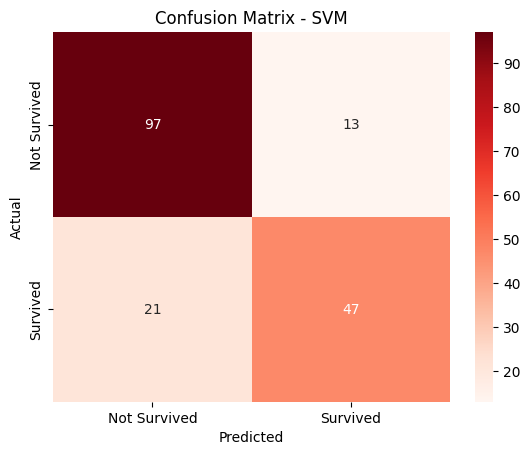

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualize
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

In [15]:
# Providing a custom data

custom_data = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],          # Male
    'AgeGroup': [2],     # 21–40
    'Fare': [80],
    'FamilySize': [1]
})

custom_scaled = scaler.transform(custom_data)

prediction = model.predict(custom_scaled)
probability = model.predict_proba(custom_scaled)

print("Prediction:", "Survived" if prediction[0] == 1 else "Did Not Survive")
print(f"Confidence (Survived): {probability[0][1]*100:.2f}%")

Prediction: Survived
Confidence (Survived): 85.93%
